# Model Results Comparison

Purpose: provide one notebook for the final comparison table across the ResNet18 and ConvNeXtV2 runs owned in this cleanup pass.

This notebook uses `reports/model_comparison/model_results_master.csv` and `reports/model_comparison/model_results_master.json` as the source of truth.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

master_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.csv'
summary_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.json'
if not master_path.exists() or not summary_path.exists():
    display(Markdown("**Model results summary not found. Rebuilding from local metric artifacts...**"))
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)

master = pd.read_csv(master_path)
summary = json.loads(summary_path.read_text(encoding='utf-8'))

metric_cols = [
    'model_name', 'run_group', 'pretrained', 'seed', 'split',
    'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
    'best_epoch', 'epochs_trained', 'recommendation', 'notes'
]

loaded_rows = master[master['status'] == 'loaded'].copy()
missing_rows = master[master['status'] != 'loaded'].copy()
if missing_rows.empty:
    display(Markdown(f"**Artifact status:** all `{len(master)}` result rows loaded from local metrics."))
else:
    display(Markdown(
        f"**Artifact status:** `{len(loaded_rows)}` loaded, `{len(missing_rows)}` missing. "
        "Missing rows mean the ignored metric/checkpoint artifacts are not present locally. "
        "Run the reproduction commands in this notebook, then rerun `python -m src.evaluation.build_model_results_master`."
    ))
    display(missing_rows[['model_family', 'run_group', 'seed', 'status', 'metrics_file']].head(20))

def rebuild_master_results():
    """Rebuild reports/model_comparison from whatever metric artifacts exist locally."""
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)
    return pd.read_csv(master_path)

**Artifact status:** all `18` result rows loaded from local metrics.

In [2]:
master.sort_values(['model_family', 'run_group', 'seed'])[metric_cols]

,model_name,run_group,pretrained,seed,split,accuracy,precision_macro,recall_macro,f1_macro,best_epoch,epochs_trained,recommendation,notes
14,ConvNeXtV2 Tiny pretrained fine-tune,convnextv2_pretrained_finetune_suspect,True,NaN,local tune split from pretrained artifact,1.000000,1.000000,1.000000,1.000000,1.0,NaN,failed/suspect run,Accuracy is 0.25 on a tiny/support-limited tun...
13,ConvNeXtV2 Tiny pretrained linear probe seed123,convnextv2_pretrained_linear_probe,True,123.0,local tune split from pretrained artifact,1.000000,1.000000,1.000000,1.000000,4.0,NaN,comparison only,Second pretrained ConvNeXt linear-probe artifact.
12,ConvNeXtV2 Tiny pretrained linear probe,convnextv2_pretrained_linear_probe,True,NaN,local tune split from pretrained artifact,0.998214,0.998227,0.998214,0.998214,6.0,NaN,comparison only,Pretrained ConvNeXt linear-probe artifact from...
15,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,42.0,strict contiguous split seed 42,0.991071,0.991133,0.991071,0.991045,27.0,29.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...
16,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,123.0,strict contiguous split seed 123,0.957143,0.957790,0.957143,0.957109,22.0,32.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...
17,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,999.0,strict contiguous split seed 999,0.978571,0.979279,0.978571,0.978561,12.0,22.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...
2,ResNet18 fine-tuned last block,resnet18_pretrained_finetune_last_block_origin...,True,NaN,original split_manifest.csv,1.000000,1.000000,1.000000,1.000000,1.0,10.0,strong baseline,Original-split fine-tuned transfer-learning run.
3,ResNet18 fine-tuned last block strict split,resnet18_pretrained_finetune_last_block_strict,True,42.0,strict contiguous split seed 42,1.000000,1.000000,1.000000,1.000000,4.0,10.0,headline transfer-learning comparison,Strict split transfer-learning run for seed ro...
6,ResNet18 fine-tuned last block strict split,resnet18_pretrained_finetune_last_block_strict,True,123.0,strict contiguous split seed 123,0.992857,0.992958,0.992857,0.992831,5.0,10.0,headline transfer-learning comparison,Strict split transfer-learning run for seed ro...
9,ResNet18 fine-tuned last block strict split,resnet18_pretrained_finetune_last_block_strict,True,999.0,strict contiguous split seed 999,1.000000,1.000000,1.000000,1.000000,1.0,10.0,headline transfer-learning comparison,Strict split transfer-learning run for seed ro...


In [3]:
summary_rows = []
for run_group, values in summary['summary_by_run_group'].items():
    row = {'run_group': run_group}
    row.update(values)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values('mean_accuracy', ascending=False)

,run_group,loaded_runs,mean_accuracy,min_accuracy,max_accuracy,mean_f1_macro,min_f1_macro,max_f1_macro
0,convnextv2_pretrained_finetune_suspect,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,resnet18_pretrained_finetune_last_block_origin...,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,convnextv2_pretrained_linear_probe,2,0.999107,0.998214,1.000000,0.999107,0.998214,1.000000
4,resnet18_pretrained_finetune_last_block_strict,3,0.997619,0.992857,1.000000,0.997610,0.992831,1.000000
7,resnet18_scratch_20ep_strict,3,0.995238,0.991071,0.998214,0.995238,0.991071,0.998214
6,resnet18_pretrained_frozen_no_aug,1,0.994643,0.994643,0.994643,0.994643,0.994643,0.994643
5,resnet18_pretrained_frozen_augmented,1,0.994643,0.994643,0.994643,0.994630,0.994630,0.994630
8,resnet18_scratch_50ep_early_stopped_strict,3,0.989286,0.982143,0.994643,0.989277,0.982099,0.994643
2,convnextv2_scratch_50ep_early_stopped_strict,3,0.975595,0.957143,0.991071,0.975572,0.957109,0.991045


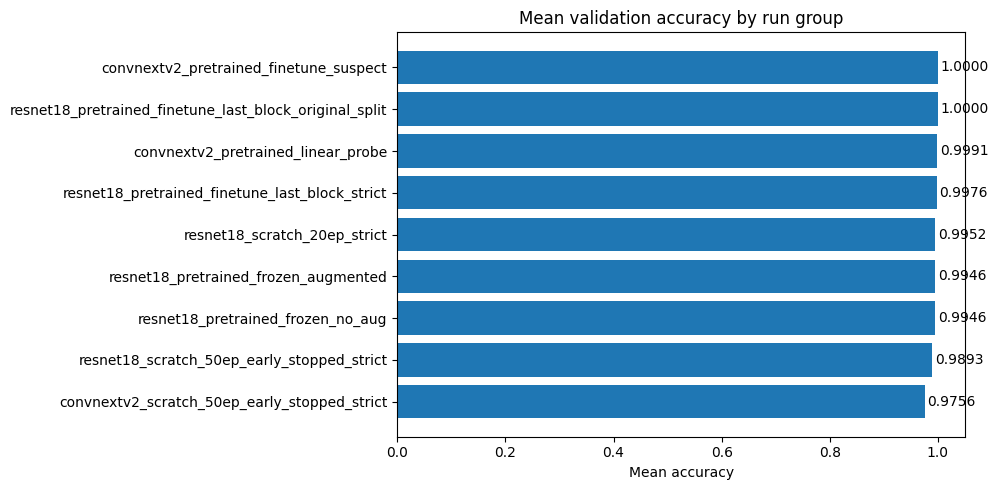

In [4]:
plot_df = summary_df.dropna(subset=['mean_accuracy']).sort_values('mean_accuracy')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['run_group'], plot_df['mean_accuracy'])
ax.set_xlabel('Mean accuracy')
ax.set_xlim(0, 1.05)
ax.set_title('Mean validation accuracy by run group')
for idx, value in enumerate(plot_df['mean_accuracy']):
    ax.text(value + 0.005, idx, f'{value:.4f}', va='center')
plt.tight_layout()
plt.show()

## Deployment-Oriented Interpretation

For deployment, use a reliable and simple model first. ResNet18 transfer learning remains the safest first ONNX export candidate because it is smaller and easier to explain than ConvNeXt while still performing strongly.

ConvNeXt scratch and pretrained results remain useful for comparison and discussion, especially around pretrained versus non-pretrained behavior.